### L1(Lasso regularization)
### L2(Ridge Regularization)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
dataset = pd.read_csv("housing_dataset.csv")


In [3]:
dataset.head(3)

,Size(sqft),Bedrooms,Bathrooms,Age,Garage,LocationScore,Price
0,3974,3,1,43,1,5,645855
1,1660,3,1,16,1,9,307825
2,2094,1,3,37,1,1,377043


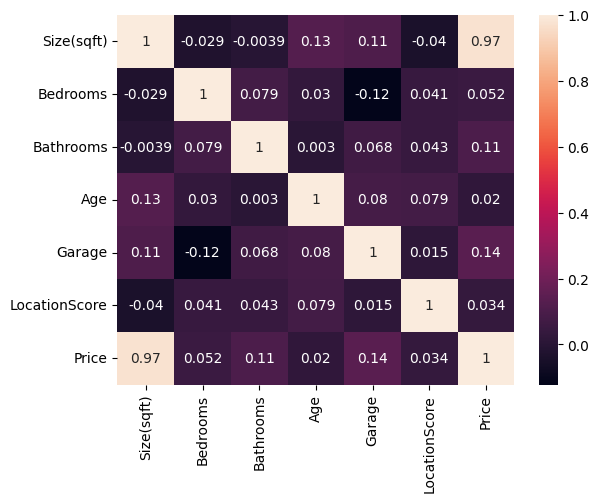

In [4]:
sns.heatmap(dataset.corr(), annot=True)
plt.show()

In [7]:
x = dataset.iloc[:, :-1]
y = dataset["Price"]

In [8]:
sc = StandardScaler()
sc.fit(x)
sc.transform(x)

array([[ 1.63405452,  0.15211402, -1.09268363,  1.27578172,  0.9900495 ,
        -0.18026867],
       [-0.94799309,  0.15211402, -1.09268363, -0.54387525,  0.9900495 ,
         1.27644783],
       [-0.46371968, -1.29659092,  1.32208682,  0.87141351,  0.9900495 ,
        -1.63698516],
       ...,
       [ 1.07725169,  0.87646649, -1.09268363, -1.55479579, -1.0100505 ,
        -1.63698516],
       [-0.82301931,  1.60081896,  0.1147016 , -0.94824347, -1.0100505 ,
         0.18391046],
       [ 0.06518722, -1.29659092,  0.1147016 ,  0.93880821,  0.9900495 ,
         0.54808958]], shape=(200, 6))

In [9]:
# In a dataframe, if we have a feature which is not correlated with the target variable, then we can drop that feature.
# If we have a feature which is highly correlated with the target variable, then we can keep that feature.
x = pd.DataFrame(sc.transform(x), columns=x.columns)
x

,Size(sqft),Bedrooms,Bathrooms,Age,Garage,LocationScore
0,1.634055,0.152114,-1.092684,1.275782,0.990050,-0.180269
1,-0.947993,0.152114,-1.092684,-0.543875,0.990050,1.276448
2,-0.463720,-1.296591,1.322087,0.871414,0.990050,-1.636985
3,-0.646717,1.600819,0.114702,-1.217822,0.990050,-0.180269
4,-0.685771,-1.296591,-1.092684,1.410571,0.990050,0.183910
...,...,...,...,...,...,...
195,-0.450330,-0.572238,0.114702,-0.274296,-1.010051,0.548090
196,1.082831,0.152114,1.322087,-0.746059,0.990050,1.276448
197,1.077252,0.876466,-1.092684,-1.554796,-1.010051,-1.636985
198,-0.823019,1.600819,0.114702,-0.948243,-1.010051,0.183910


In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error



In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)    
lr.score(x_test, y_test)    

0.9788617417293551

In [25]:
# finding error values for linear regression
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

426632927.7129324
15758.437814995526
20655.094473590103


In [13]:
lr.coef_

array([135519.58265648,  10183.25394746,  14261.71757958, -17010.02905628,
         4995.26927823,  10117.46694555])

In [ ]:
# Give cols names
x.columns

Index(['Size(sqft)', 'Bedrooms', 'Bathrooms', 'Age', 'Garage',
       'LocationScore'],
      dtype='object')

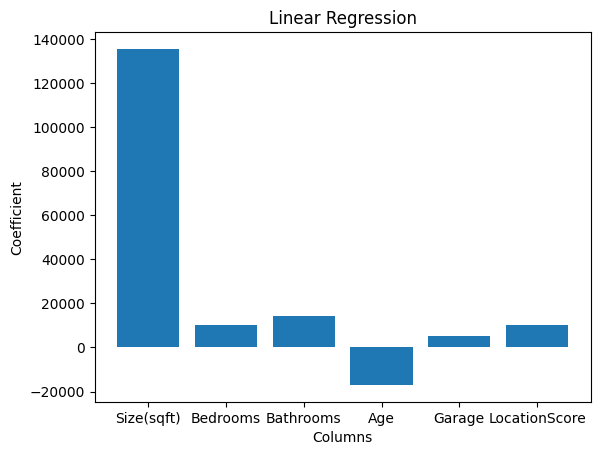

In [ ]:
# linear regression coefficients
plt.bar(x.columns, lr.coef_)
plt.title("Linear Regression")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

In [17]:
# Lasso Regression(feature selection)
lasso = Lasso(alpha=0.5)
lasso.fit(x_train, y_train)
lasso.score(x_test, y_test)

0.9788618272563625

In [26]:
# Error values for lasso regression
print(mean_squared_error(y_test, lasso.predict(x_test)))
print(mean_absolute_error(y_test, lasso.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lasso.predict(x_test))))


426631201.5235244
15758.448434834538
20655.052687502986


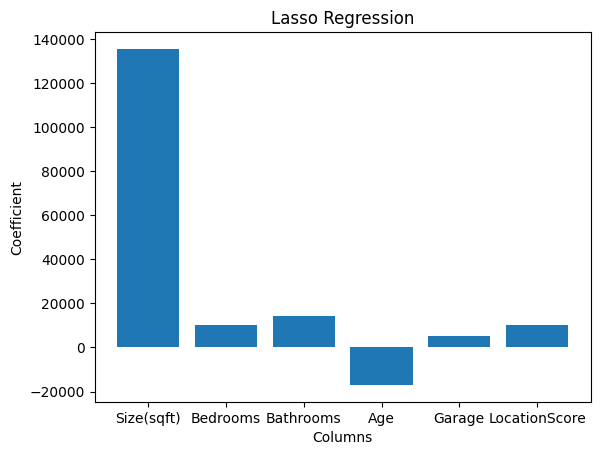

In [18]:
# Lasso Regression
plt.bar(x.columns, lasso.coef_)
plt.title("Lasso Regression")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

In [ ]:
# Ridge Regression
# continously changing allpha value and checking the score gives better results
ridge = Ridge(alpha=10)
ridge.fit(x_train, y_train)
ridge.score(x_test, y_test)

0.9749913786357688

In [28]:
# Error values for lasso regression
print(mean_squared_error(y_test, ridge.predict(x_test)))
print(mean_absolute_error(y_test, ridge.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ridge.predict(x_test))))

504748367.3478958
17715.441990000083
22466.605603604115


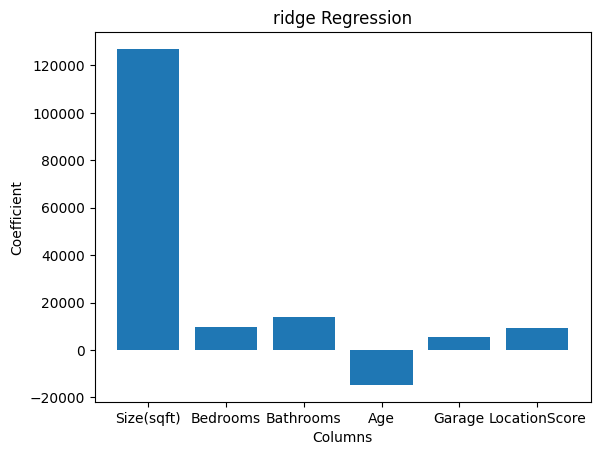

In [20]:
# Ridge Regression
plt.bar(x.columns, ridge.coef_)
plt.title("ridge Regression")
plt.xlabel("Columns")
plt.ylabel("Coefficient")
plt.show()

In [29]:
# Comparing Coefficients of all three models
df = pd.DataFrame({"col_name":x.columns,"Linear Regression": lr.coef_, "Lasso Regression": lasso.coef_, "Ridge Regression": ridge.coef_})

In [30]:
df

,col_name,Linear Regression,Lasso Regression,Ridge Regression
0,Size(sqft),135519.582656,135519.054335,126960.066192
1,Bedrooms,10183.253947,10182.756026,9641.966723
2,Bathrooms,14261.717580,14261.347260,13896.456887
3,Age,-17010.029056,-17009.328982,-14754.324530
4,Garage,4995.269278,4994.705272,5268.263130
5,LocationScore,10117.466946,10116.962162,9320.538313
